Linear Regression         | R²=0.5737 | RMSE=409.10 | MAE=305.37
Ridge Regression          | R²=0.5737 | RMSE=409.09 | MAE=305.38
Lasso Regression          | R²=0.5733 | RMSE=409.27 | MAE=305.74
Elastic Net               | R²=0.5159 | RMSE=435.94 | MAE=322.58


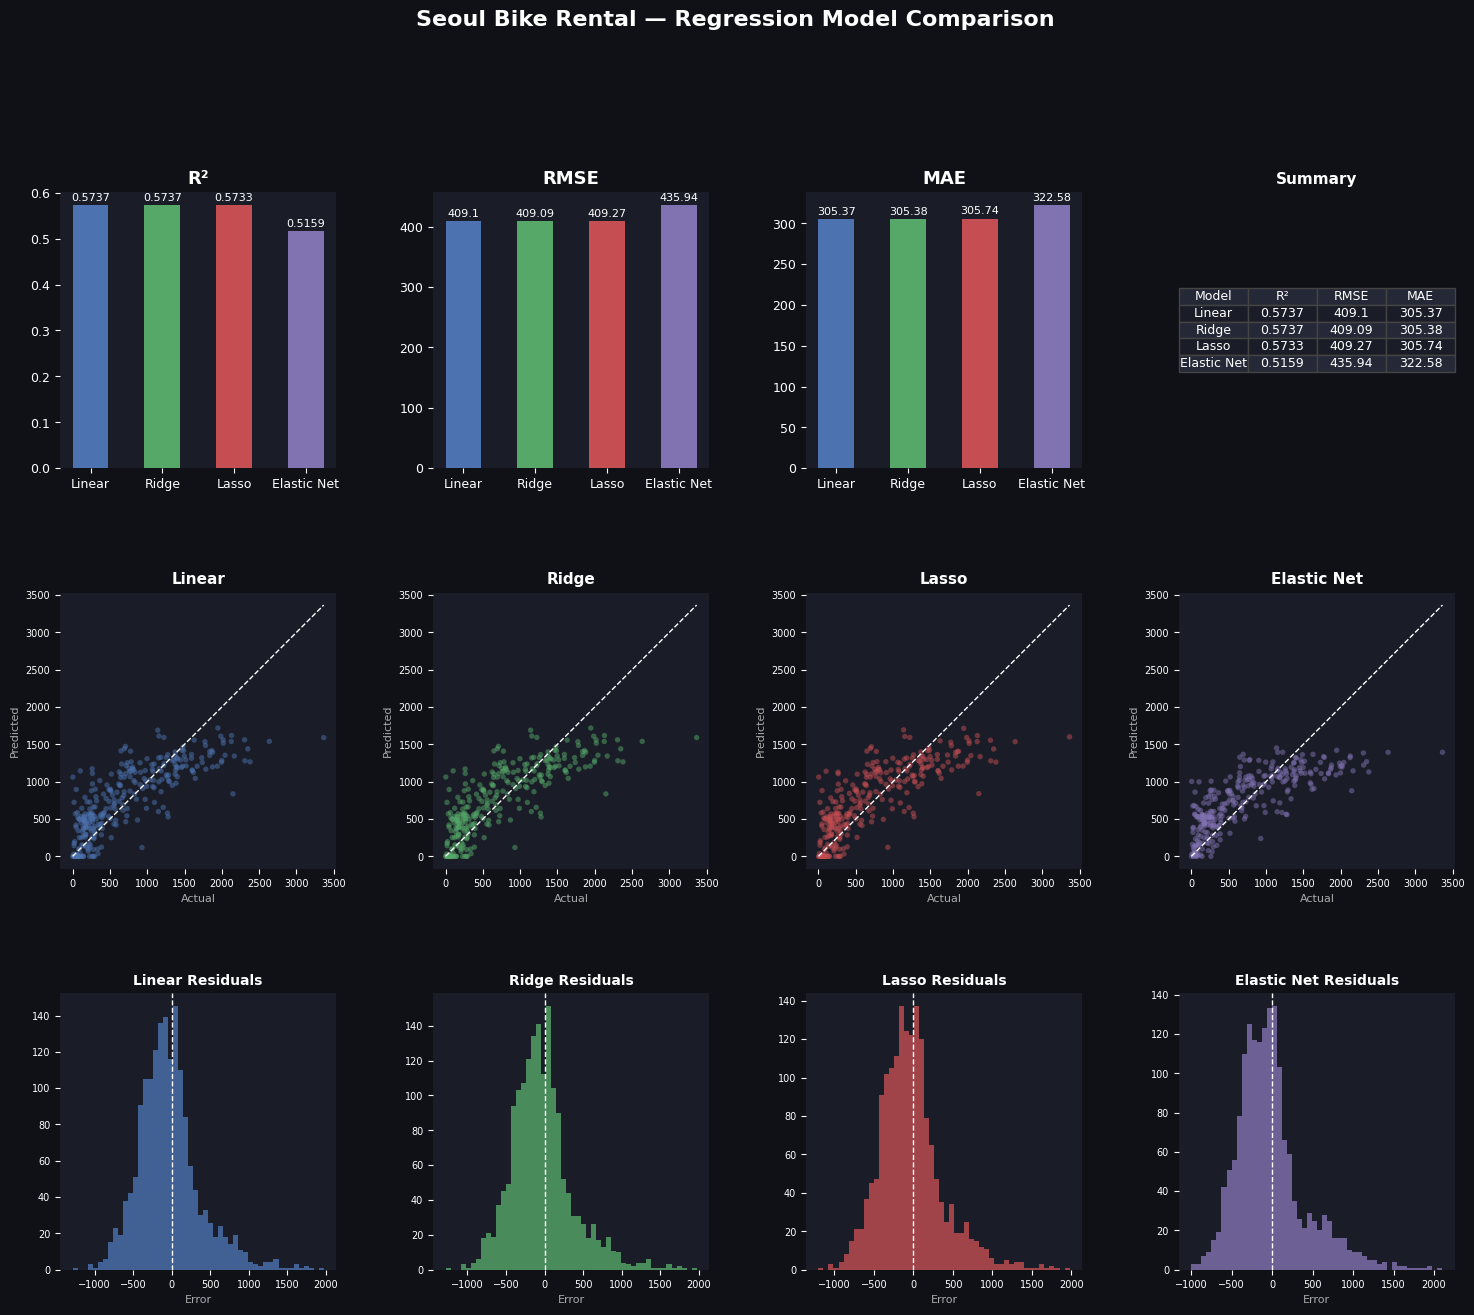

Done! Plot saved as regression_comparison.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


df = pd.read_csv('SeoulBikeData.csv', encoding='latin1')

df = df[df['Functioning Day'] == 'Yes'].drop(columns=['Date', 'Functioning Day'])


df = pd.get_dummies(df, columns=['Seasons', 'Holiday'], drop_first=True)

X = df.drop(columns=['Rented Bike Count'])
y = df['Rented Bike Count']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Lasso Regression' : Lasso(alpha=1.0),
    'Elastic Net'      : ElasticNet(alpha=1.0, l1_ratio=0.5),
    
}

results = {}
preds   = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    yp = model.predict(X_test_s)
    yp = np.clip(yp, 0, None)          

    r2   = r2_score(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    mae  = mean_absolute_error(y_test, yp)

    results[name] = {'R²': round(r2, 4), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}
    preds[name]   = yp

    print(f'{name:25s} | R²={r2:.4f} | RMSE={rmse:.2f} | MAE={mae:.2f}')

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
names  = list(results.keys())
short  = ['Linear', 'Ridge', 'Lasso', 'Elastic Net']

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0F1117')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

metrics     = ['R²', 'RMSE', 'MAE']
metric_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

for ax, metric in zip(metric_axes, metrics):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(short, vals, color=colors, edgecolor='none', width=0.5)
    ax.set_title(metric, color='white', fontsize=13, fontweight='bold')
    ax.set_facecolor('#1A1D27')
    ax.tick_params(colors='white', labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{val}', ha='center', va='bottom', color='white', fontsize=8
        )

ax_tbl = fig.add_subplot(gs[0, 3])
ax_tbl.set_facecolor('#1A1D27')
ax_tbl.axis('off')
col_labels = ['Model', 'R²', 'RMSE', 'MAE']
rows = [
    [s, results[n]['R²'], results[n]['RMSE'], results[n]['MAE']]
    for s, n in zip(short, names)
]
tbl = ax_tbl.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#252836' if r % 2 == 0 else '#1A1D27')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#444')
ax_tbl.set_title('Summary', color='white', fontsize=11, fontweight='bold')


sample   = np.random.choice(len(y_test), 300, replace=False)
y_sample = np.array(y_test)[sample]

for i, (name, color) in enumerate(zip(names, colors)):
    ax = fig.add_subplot(gs[1, i])
    ax.scatter(y_sample, preds[name][sample], alpha=0.5, color=color, s=15, edgecolors='none')
    mx = max(y_sample.max(), preds[name][sample].max())
    ax.plot([0, mx], [0, mx], 'w--', linewidth=1)
    ax.set_facecolor('#1A1D27')
    ax.set_title(short[i], color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual',    color='#aaa', fontsize=8)
    ax.set_ylabel('Predicted', color='#aaa', fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_visible(False)

for i, (name, color) in enumerate(zip(names, colors)):
    ax        = fig.add_subplot(gs[2, i])
    residuals = np.array(y_test) - preds[name]
    ax.hist(residuals, bins=50, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(0, color='white', linestyle='--', linewidth=1)
    ax.set_facecolor('#1A1D27')
    ax.set_title(f'{short[i]} Residuals', color='white', fontsize=10, fontweight='bold')
    ax.set_xlabel('Error', color='#aaa', fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle(
    'Seoul Bike Rental — Regression Model Comparison',
    color='white', fontsize=16, fontweight='bold', y=1.01
)

plt.savefig('regression_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Done! Plot saved as regression_comparison.png')